# 07. なぜ Hfq を増やすと逆に効かなくなるのか — 結合の「順序」が生む Hfq set-point

> **出典**: Sagawa S, Shin J-E, Hussein R, Lim HN (2015) *Paradoxical suppression of small RNA activity at high Hfq concentrations due to random-order binding.* Nucleic Acids Res 43(17):8502-8515.

06 で「Hfq に対して duplex は釣鐘状」を見た。07 はその**釣鐘の右肩下がり（高 Hfq での抑制）が、なぜ起きるのか**を突き止める。

sRNA と mRNA は、**どちらが先に Hfq に乗ってもよい**（random order）。論文の主張はこうだ:

> **random-order だからこそ、高 Hfq で sRNA 活性が落ちる。** もし *compulsory-order*（必ず sRNA が先に Hfq に乗る）なら、
> 高 Hfq でも単調に飽和するだけで、抑制は起きない。

つまり「最適 Hfq（Hfq set-point）」は、結合の順序が生み出す性質。モデルは 06 とほぼ同じで、**違いは1点だけ**:

| モード | Hfq への結合 |
|---|---|
| **random** | $s+H\rightleftharpoons sH$ と $m+H\rightleftharpoons mH$ の両方（mRNA も単独で乗れる） |
| **compulsory** | $s+H\rightleftharpoons sH$ のみ（mRNA は $sH$ にしか結合しない = 必ず sRNA が先） |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

H, S, M, SH, MH, T, D = (Species(x) for x in ['H','s','m','sH','mH','T','D'])
A_S = A_M = 10.0
BETA, KA, KD, K5 = 1.0, 1.0, 1.0, 10.0
SP = ['H','s','m','sH','mH','T','D']
def R(a,b,k): return ReactionRule(a,b,k)

def build(h_tot, mode):
    common = [R([],[S],A_S), R([],[M],A_M), R([S],[],BETA), R([M],[],BETA),
              R([S,H],[SH],KA), R([SH],[S,H],KD),
              R([SH,M],[T],KA), R([T],[SH,M],KD),
              R([T],[D,H],K5), R([SH],[H],BETA), R([T],[H],BETA), R([D],[],BETA)]
    random_extra = [R([M,H],[MH],KA), R([MH],[M,H],KD),
                    R([MH,S],[T],KA), R([T],[MH,S],KD), R([MH],[H],BETA)]
    mdl = NetworkModel()
    for r in common + (random_extra if mode == 'random' else []):
        mdl.add_reaction_rule(r)
    return mdl

def steady(h_tot, mode):
    ret = run_simulation(400.0, y0={'H': h_tot}, model=build(h_tot, mode),
                         solver='ode', ndiv=1, species_list=SP)
    return dict(zip(SP, ret.as_array()[-1][1:]))

def pct_duplex(h_tot, mode):
    v = steady(h_tot, mode); tot_m = v['m']+v['mH']+v['T']+v['D']
    return 100*v['D']/tot_m if tot_m > 0 else 0.0
print('ready')

ready


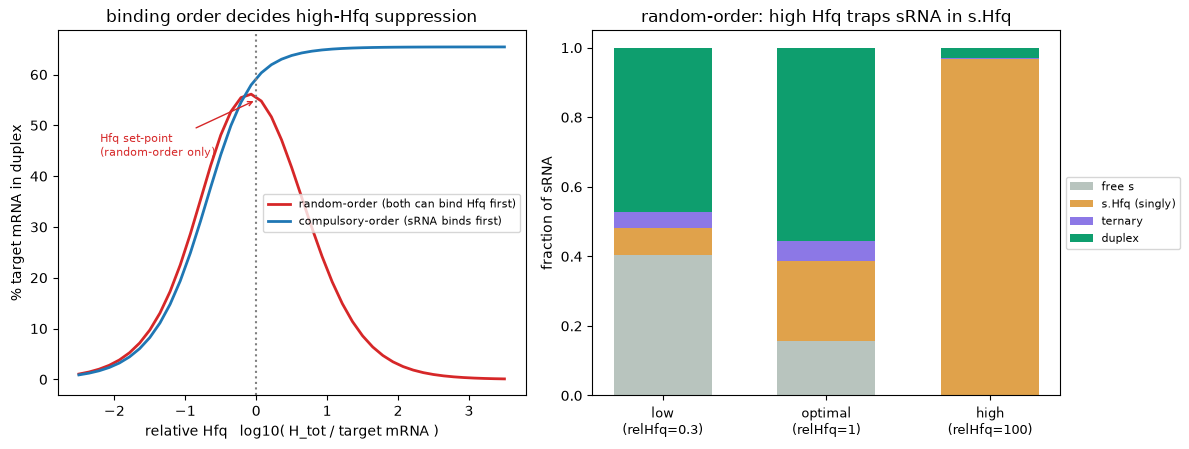

In [2]:
rel = np.logspace(-2.5, 3.5, 43)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for mode, c, lab in [('random','C3','random-order (both can bind Hfq first)'),
                     ('compulsory','C0','compulsory-order (sRNA binds first)')]:
    y = np.array([pct_duplex(r*10, mode) for r in rel])
    ax1.plot(np.log10(rel), y, '-', color=c, lw=2, label=lab)
ax1.axvline(0, ls=':', c='gray')
ax1.annotate('Hfq set-point\n(random-order only)', xy=(0,55), xytext=(-2.2,44), fontsize=8, color='C3',
             arrowprops=dict(arrowstyle='->', color='C3', lw=1))
ax1.set_xlabel('relative Hfq   log10( H_tot / target mRNA )')
ax1.set_ylabel('% target mRNA in duplex'); ax1.set_title('binding order decides high-Hfq suppression'); ax1.legend(fontsize=8)

parts, plab = ['s','sH','T','D'], ['free s','s.Hfq (singly)','ternary','duplex']
cols = ['#b8c4be','#e0a24b','#8c78e6','#0e9e6e']
data = np.array([[ (lambda v: v[p]/(v['s']+v['sH']+v['T']+v['D']))(steady(r*10,'random')) for p in parts]
                 for r in [0.3,1.0,100.0]])
bottom = np.zeros(3); x = np.arange(3)
for j,(pl,col) in enumerate(zip(plab,cols)):
    ax2.bar(x, data[:,j], bottom=bottom, color=col, label=pl, width=.6); bottom += data[:,j]
ax2.set_xticks(x); ax2.set_xticklabels(['low\n(relHfq=0.3)','optimal\n(relHfq=1)','high\n(relHfq=100)'], fontsize=9)
ax2.set_ylabel('fraction of sRNA'); ax2.set_title('random-order: high Hfq traps sRNA in s.Hfq')
ax2.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0,0.5))
plt.tight_layout(); plt.show()

## 読み取り

- **左**: 2曲線は最適 Hfq（set-point, relHfq≈1）まで一緒に登る。だがそこから先で分岐する——
  **random-order（赤）は落ちる**（paradoxical suppression）が、**compulsory-order（青）は飽和するだけ**で落ちない。
  高 Hfq での抑制は「Hfq が足りない」からではなく、**結合順序**が原因。
- **右**: random-order で高 Hfq だと、sRNA のほとんどが単独の $s\cdot$Hfq に囚われる。パートナー mRNA も別の $m\cdot$Hfq に
  乗ってしまい、両者が出会って三者複合体を作れない。だから duplex が崩壊する。
- **なぜ compulsory だと平気か**: mRNA は $sH$ にしか結合できない＝mRNA 単独の $m\cdot$Hfq という「行き止まり」が存在しない。
  Hfq を増やしても sRNA が $sH$ になるだけで、mRNA はそこへ着実に来られる。

**06 との関係**: 06 の釣鐘の右肩は、まさにこの random-order 由来の抑制だった。07 はその原因を「順序」に特定した。

## 発展課題（自作）

1. random-order で会合 `KA` を上げる（Hfq に乗りやすくする）と、抑制はどう変わる？ set-point の位置は動く？
2. compulsory を「mRNA が必ず先」に入れ替えても（$m+H$ のみ）、同じく単調飽和になるか確かめる。
3. 論文にはもう一つ **mRNA set-point** がある: mRNA-Hfq が三者に進めない「行き止まり」の場合（$mH+s\to T$ を消す）、
   mRNA を増やすと Hfq が $mH$ に隔離され sRNA 活性が落ちる。これを作って確認する。
4. [[bio-a_hfq-phylogenetics]]: オーソログで結合が compulsory 寄りか random 寄りかが違えば、
   同じ Hfq 量でも「高 Hfq に強いか弱いか」が変わる。結合機構の進化を、この頑健性の差として解釈してみる。